# Coffee Data Analysis

## AD450 – Week 5

This analysis examines historical coffee production, exports, and imports to identify major exporters, producers, hidden production opportunities, and global trade patterns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
exports = pd.read_csv("Coffee_export.csv")
imports = pd.read_csv("Coffee_import.csv")
production = pd.read_csv("Coffee_production.csv")

print("Exports:", exports.shape)
print("Imports:", imports.shape)
print("Production:", production.shape)

Exports: (55, 32)
Imports: (35, 32)
Production: (55, 33)


In [3]:
display(exports.head())
display(imports.head())
display(production.head())

,Country,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,Total_export
0,Angola,5040000,4260000,4800000,2340000,480000,2460000,3120000,3000000,3240000,...,480000,480000,360000,540000,660000,660000,540000,540000,1380000,43320000
1,Bolivia (Plurinational State of),9360000,4440000,5760000,2820000,5040000,5640000,7380000,6660000,5820000,...,4440000,3780000,3300000,3720000,1800000,1320000,1560000,1320000,1200000,137460000
2,Brazil,1016160000,1270980000,1127460000,1070280000,1036380000,868080000,915060000,1008060000,1088640000,...,2028360000,1712940000,1899060000,-2147483648,-2147483648,2056140000,1855500000,2138220000,-2147483648,33807709056
3,Burundi,35100000,41280000,38760000,25080000,30480000,31680000,13440000,31740000,22440000,...,13080000,23520000,11700000,15120000,13800000,12240000,10140000,12120000,17580000,646200000
4,Cameroon,156660000,105120000,98760000,42300000,32760000,24420000,33840000,82080000,44760000,...,29400000,37320000,16320000,22500000,23400000,16860000,14700000,17220000,15000000,1399920000


,Country,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,Total_import
0,Austria,112800000,123480000,132360000,110160000,85020000,73860000,72600000,77640000,77580000,...,87120000,93540000,93300000,91500000,90780000,89700000,87600000,85740000,86880000,2765760000
1,Belgium,0,0,0,0,0,0,0,0,0,...,349680000,340080000,330120000,312720000,332040000,363120000,340620000,344520000,371940000,6240540000
2,Belgium/Luxembourg,120900000,104760000,109680000,123780000,135720000,144060000,151560000,152640000,214800000,...,0,0,0,0,0,0,0,0,0,1257900000
3,Bulgaria,16080000,12000000,10920000,23820000,27780000,30900000,16320000,17640000,20520000,...,28920000,33600000,36540000,37260000,40920000,46740000,42420000,44220000,47100000,830700000
4,Croatia,0,0,10080000,9780000,11580000,19200000,19320000,23100000,20340000,...,23460000,23040000,24780000,25200000,26220000,28740000,26340000,26760000,27960000,622080000


,Country,Coffee type,1990/91,1991/92,1992/93,1993/94,1994/95,1995/96,1996/97,1997/98,...,2011/12,2012/13,2013/14,2014/15,2015/16,2016/17,2017/18,2018/19,2019/20,Total_production
0,Angola,Robusta/Arabica,3.000000e+06,4.740000e+06,4.680000e+06,1.980000e+06,4.620000e+06,3.720000e+06,4.260000e+06,3.840000e+06,...,1.740000e+06,1.980000e+06,2.100000e+06,2.340000e+06,2.460000e+06,2.700000e+06,2.100000e+06,2.520000e+06,3.120000e+06,8.208000e+07
1,Bolivia (Plurinational State of),Arabica,7.380000e+06,6.240000e+06,7.200000e+06,3.060000e+06,7.020000e+06,8.520000e+06,7.500000e+06,8.460000e+06,...,7.920000e+06,6.300000e+06,7.200000e+06,6.000000e+06,5.040000e+06,4.680000e+06,5.040000e+06,4.980000e+06,4.860000e+06,2.070000e+08
2,Brazil,Arabica/Robusta,1.637160e+09,1.637580e+09,2.076180e+09,1.690020e+09,1.691520e+09,1.083600e+09,1.751820e+09,1.568880e+09,...,2.915520e+09,3.325080e+09,3.281340e+09,3.198300e+09,3.172260e+09,3.407280e+09,3.164400e+09,3.907860e+09,3.492660e+09,7.508298e+10
3,Burundi,Arabica/Robusta,2.922000e+07,4.002000e+07,3.720000e+07,2.358000e+07,3.984000e+07,2.604000e+07,2.406000e+07,1.500000e+07,...,1.224000e+07,2.436000e+07,9.780000e+06,1.488000e+07,1.614000e+07,1.176000e+07,1.212000e+07,1.224000e+07,1.632000e+07,6.236400e+08
4,Ecuador,Arabica/Robusta,9.024000e+07,1.274400e+08,7.110000e+07,1.241400e+08,1.425600e+08,1.132800e+08,1.195800e+08,7.146000e+07,...,4.950000e+07,4.968000e+07,3.996000e+07,3.864000e+07,3.864000e+07,3.870000e+07,3.744000e+07,2.976000e+07,3.354000e+07,1.900380e+09


## 1. Largest Coffee Exporter, 1990–1994

The goal is to identify the country with the largest total coffee export volume from 1990 through 1994.

In [4]:
export_years = ["1990", "1991", "1992", "1993", "1994"]

exports["1990_1994_total"] = exports[export_years].sum(axis=1)

top_exporter = (
    exports[["Country", "1990_1994_total"]]
    .sort_values("1990_1994_total", ascending=False)
    .head(1)
)

display(top_exporter)

,Country,1990_1994_total
2,Brazil,5521260000


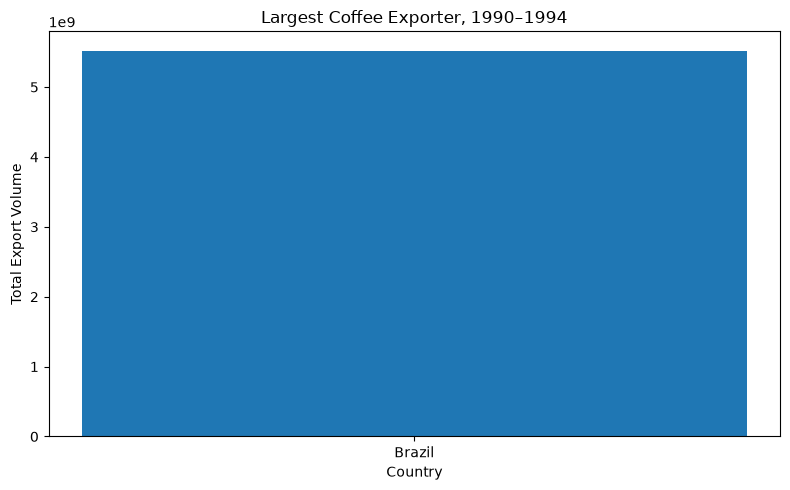

In [5]:
plt.figure(figsize=(8, 5))

plt.bar(
    top_exporter["Country"],
    top_exporter["1990_1994_total"]
)

plt.title("Largest Coffee Exporter, 1990–1994")
plt.xlabel("Country")
plt.ylabel("Total Export Volume")

plt.tight_layout()
plt.show()

### Stakeholder Summary

The analysis identifies the country with the highest total coffee export volume between 1990 and 1994. This information can help the company understand historical export leadership and identify countries that have played an important role in the global coffee supply chain.

### Data Limitation

The export dataset provides country-level annual totals but does not identify individual exporter-to-importer transactions. Therefore, the analysis can identify major exporting countries but cannot determine exactly which countries received those exports.

## 2. Top 5 Coffee Producers, 1999–2004

This analysis identifies the five countries with the highest cumulative coffee production from the 1999/00 through 2004/05 production years.

In [6]:
production_years = [
    "1999/00",
    "2000/01",
    "2001/02",
    "2002/03",
    "2003/04",
    "2004/05"
]

production["1999_2004_total"] = production[production_years].sum(axis=1)

top_producers = (
    production.groupby("Country")["1999_2004_total"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

top_producers.insert(0, "Rank", range(1, 6))

display(top_producers)

,Rank,Country,1999_2004_total
0,1,Brazil,1.360554e+10
1,2,Viet Nam,4.850760e+09
2,3,Colombia,3.970500e+09
3,4,Indonesia,2.462880e+09
4,5,India,1.715040e+09


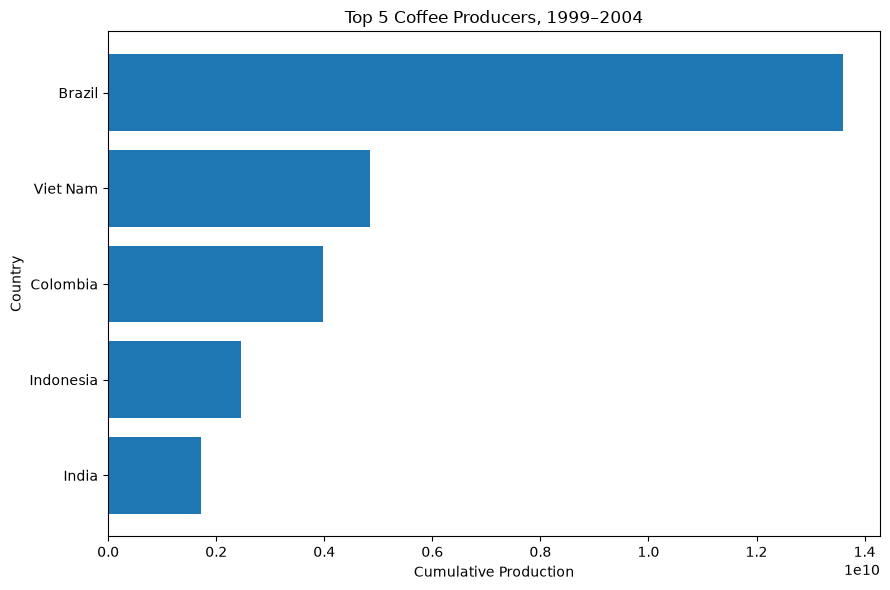

In [7]:
plt.figure(figsize=(9, 6))

plt.barh(
    top_producers["Country"],
    top_producers["1999_2004_total"]
)

plt.title("Top 5 Coffee Producers, 1999–2004")
plt.xlabel("Cumulative Production")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Hidden Gems by Coffee Type, 1990–1994

For each coffee type, this analysis identifies the country with the second-highest cumulative production between 1990 and 1994. Statistical ties are preserved.

In [ ]:
production_years_90_94 = [
    "1990/91",
    "1991/92",
    "1992/93",
    "1993/94",
    "1994/95"
]

hidden_gems = production[
    ["Country", "Coffee type"] + production_years_90_94
].copy()

hidden_gems["1990_1994_total"] = hidden_gems[
    production_years_90_94
].sum(axis=1)

hidden_gems = (
    hidden_gems
    .groupby(["Coffee type", "Country"])["1990_1994_total"]
    .sum()
    .reset_index()
)

hidden_gems["Rank"] = (
    hidden_gems
    .groupby("Coffee type")["1990_1994_total"]
    .rank(method="min", ascending=False)
)

second_highest = hidden_gems[
    hidden_gems["Rank"] == 2
].sort_values(["Coffee type", "Country"])

display(second_highest)

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    second_highest["Country"],
    second_highest["1990_1994_total"]
)

plt.title("Second-Highest Coffee Producers by Coffee Type, 1990–1994")
plt.xlabel("Country")
plt.ylabel("Cumulative Production")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Stakeholder Summary

The hidden-gem analysis identifies countries that ranked second in production for each coffee type during 1990–1994. These countries may represent potential sourcing opportunities because they had significant production capacity without being the largest producer for their coffee type.

## 4. Global Trade Footprints

This analysis combines coffee export and import data to identify the five countries with the largest total trade volume across the full available timespan.

In [ ]:
export_totals = exports[["Country", "Total_export"]].copy()

import_totals = imports[["Country", "Total_import"]].copy()

trade = pd.merge(
    export_totals,
    import_totals,
    on="Country",
    how="outer"
)

trade["Total_export"] = trade["Total_export"].fillna(0)
trade["Total_import"] = trade["Total_import"].fillna(0)

trade["Total Trade Volume"] = (
    trade["Total_export"] + trade["Total_import"]
)

top_trade = (
    trade
    .sort_values("Total Trade Volume", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

top_trade.insert(0, "Rank", range(1, 6))

display(top_trade)

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_trade["Country"],
    top_trade["Total Trade Volume"]
)

plt.title("Top 5 Countries by Total Coffee Trade Volume")
plt.xlabel("Total Trade Volume")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Stakeholder Summary

The global trade analysis identifies the countries with the largest combined export and import volumes across the dataset's full timespan. These countries are important to the global coffee trade network and could be strategically relevant for market expansion, sourcing, logistics, or partnerships.

### Data Limitation

The export and import datasets provide country-level totals by year. They do not provide individual bilateral transactions, so total trade volume shows the scale of a country's trade activity but does not show which specific countries traded coffee with each other.

## 5. Sourcing Traceability

The available datasets cannot determine exact exporter-to-importer relationships. The export and import datasets contain country-level annual totals, while the production dataset contains country-level production by coffee type and year. There is no exporter field connected to a specific importer, shipment, transaction, or trade route.

To support exact sourcing traceability, the company would need a bilateral trade or transaction-level table containing at least:

- Exporter country
- Importer country
- Year or transaction date
- Coffee type
- Export/import volume
- Trade value
- Product classification
- Consistent country identifiers

Ideally, additional fields such as shipment ID, origin, destination, supplier, buyer, and certification information would also be included.

Therefore, the current datasets are useful for analyzing production and overall trade patterns, but they cannot trace a specific coffee shipment from an exporter to an importer.

# Overall Conclusion

The analysis shows how historical coffee production and trade data can help identify major exporters, leading producers, potential sourcing opportunities, and important global trade markets. However, the datasets provide aggregated country-level information, which limits the ability to trace individual trade relationships or shipments. For detailed supply-chain traceability, the company would need transaction-level bilateral trade data connecting exporters, importers, products, and shipment information.